In [1]:
import glob
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from matplotlib.animation import FuncAnimation

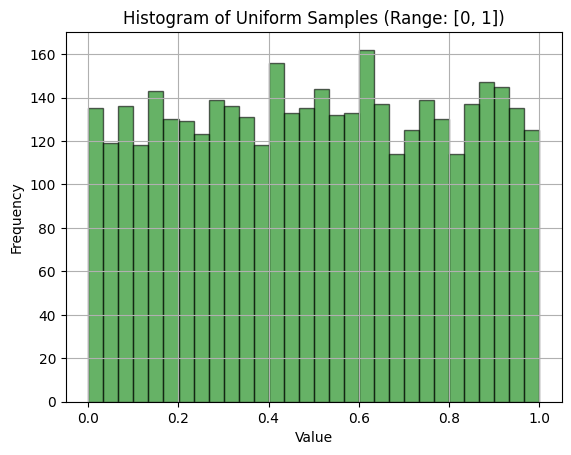

In [2]:
batch_size = 4000
# Generate sample points from a Uniform distribution (range: [low, high])
uniform_samples = np.random.uniform(low=0, high=1, size=batch_size).astype(np.float32)
uniform_samples = torch.tensor(uniform_samples).numpy()

# Plot Histogram
plt.hist(uniform_samples, bins=30, alpha=0.6, color='green', edgecolor='black')
plt.title('Histogram of Uniform Samples (Range: [0, 1])')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

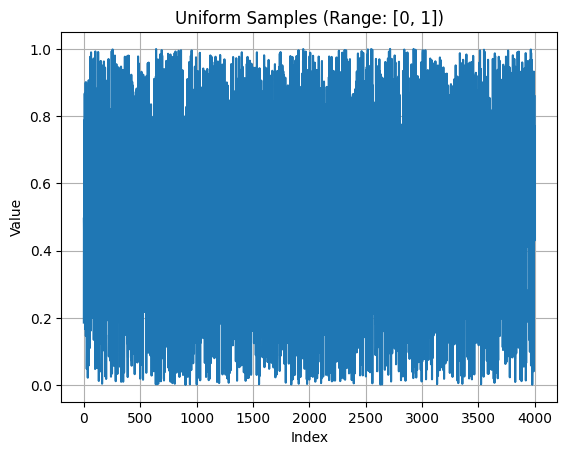

In [3]:
plt.plot(uniform_samples)
plt.title('Uniform Samples (Range: [0, 1])')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

Text(0.5, 0, 'Value')

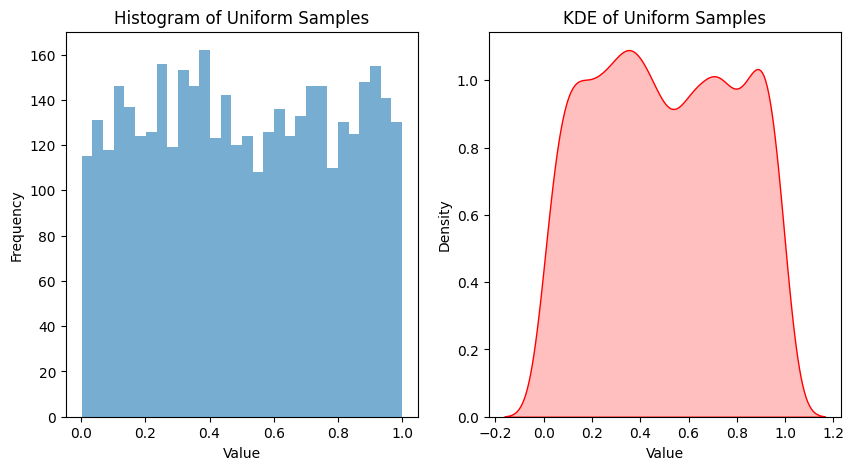

In [4]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(uniform_samples, bins=30, alpha=0.6)
plt.title('Histogram of Uniform Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(uniform_samples, color='red', fill=True)
plt.title('KDE of Uniform Samples')
plt.xlabel('Value')

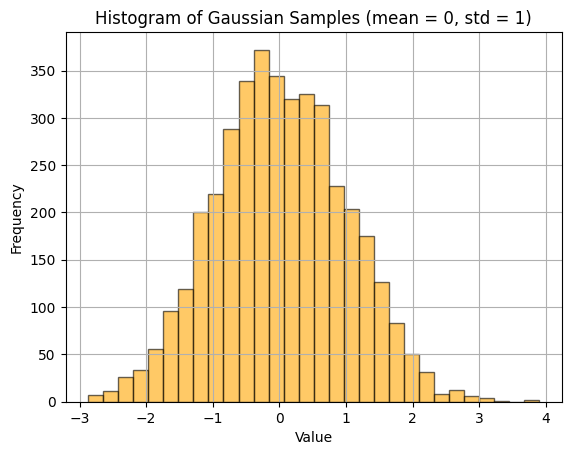

In [5]:
# Step 2: Generate 400 sample points from a Gaussian distribution (mean=0, std=1)
# gaussian_samples = np.random.normal(loc=0, scale=1, size=400).astype(np.float32)
gaussian_samples = norm.ppf(uniform_samples)
gaussian_samples = torch.tensor(gaussian_samples).numpy()

# Plot Histogram
plt.hist(gaussian_samples, bins=30, alpha=0.6, color='orange', edgecolor='black')
plt.title('Histogram of Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

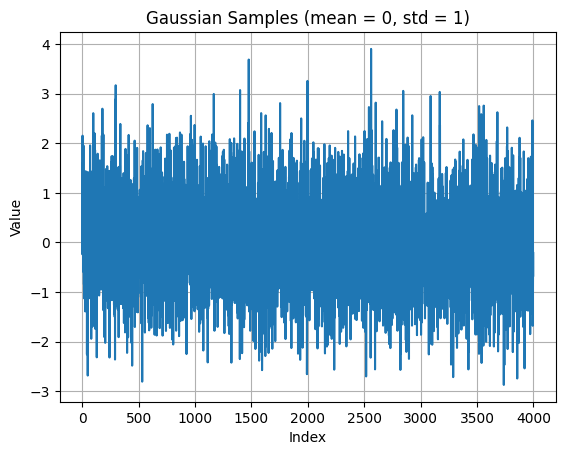

In [6]:
plt.plot(gaussian_samples)
plt.title('Gaussian Samples (mean = 0, std = 1)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()

In [ ]:
# Plot Histogram
plt.figure(figsize=(10, 5))

# Subplot 1: Histogram
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples, bins=30, alpha=0.6)
plt.title('Histogram of Gaussian Samples')
plt.xlabel('Value')
plt.ylabel('Frequency')


# Subplot 2: Kernel Density Estimate (KDE)
plt.subplot(1, 2, 2)
sns.kdeplot(gaussian_samples, color='red',label='samples')
# Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1), label = 'correct')
plt.legend()
plt.title('KDE of Gaussian Samples')
plt.xlabel('Value')

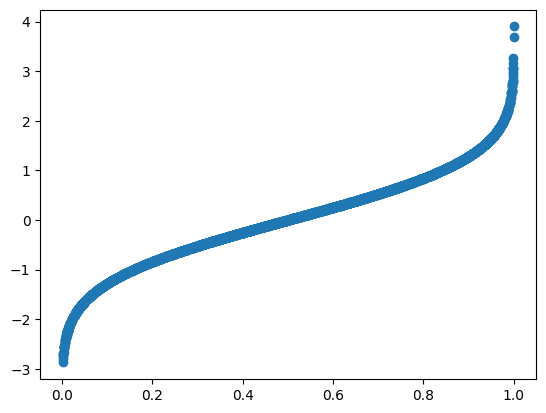

In [8]:
plt.scatter(uniform_samples, gaussian_samples)

In [9]:
uniform_samples = torch.tensor(uniform_samples).unsqueeze(1)
gaussian_samples = torch.tensor(gaussian_samples).unsqueeze(1)

In [10]:
class FNN(nn.Module):
    def __init__(self):
        super(FNN, self).__init__()
        self.fc1 = nn.Linear(1, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.fc4 = nn.Linear(64, 64)
        self.fc5 = nn.Linear(64, 64)
        self.fc6 = nn.Linear(64, 1)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.tanh(self.fc3(x))
        x = self.tanh(self.fc4(x))
        x = self.tanh(self.fc5(x))
        return self.fc6(x)

In [11]:
# Function to compute moments (mean, variance, skewness, kurtosis, and 5th moment)
def compute_moments(samples):
    mean = torch.mean(samples)
    variance = torch.var(samples, unbiased=False)  # Population variance
    skewness = torch.mean(((samples - mean) ** 3)) / (variance ** 1.5)
    kurtosis = torch.mean(((samples - mean) ** 4)) / (variance ** 2) - 3
    fifth_moment = torch.mean((samples - mean) ** 5)
    return mean, variance, skewness, kurtosis, fifth_moment

In [12]:
def compute_mean(samples):
    mean = torch.mean(samples)
    return mean

In [13]:
def compute_variance(samples):
    variance = torch.var(samples, unbiased=False)
    return variance

In [14]:
# Initialize the neural network
model = FNN()

In [15]:
compute_mean(gaussian_samples)

tensor(0.0213, dtype=torch.float64)

In [16]:
compute_variance(gaussian_samples)

tensor(0.9631, dtype=torch.float64)

In [17]:
# Define optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Initialize lists to store each moment loss over epochs
mean_loss_list = []
variance_loss_list = []
total_loss_list = []
epoch_list = []

# Training loop
num_epochs = 10000
save_interval = 10  # Save model every 10 iterations

for epoch in range(num_epochs):
    # Forward pass
    outputs = model(uniform_samples)
    
    # Compute individual moment losses
    mean_loss = torch.abs(compute_mean(outputs) - compute_mean(gaussian_samples))
    variance_loss = torch.abs(compute_variance(outputs) - compute_variance(gaussian_samples)) 

    # Total loss with weighted moments
    total_loss = mean_loss + 2*variance_loss

    # Backward pass and optimization
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    # Store each moment loss and epoch number
    mean_loss_list.append(mean_loss.item())
    variance_loss_list.append(variance_loss.item())
    total_loss_list.append(total_loss.item())
    epoch_list.append(epoch + 1)
    
    print(f'Epoch [{epoch+1}/{num_epochs}], Mean Loss: {mean_loss.item():.4f}, '
          f'Variance Loss: {variance_loss.item():.4f}, mean: {compute_mean(outputs):.4f}, variance: {compute_variance(outputs):.4f}')
    
    # Save model every 10 iterations
    if (epoch + 1) % save_interval == 0:
        torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pt")
        print(f"Model saved at epoch {epoch+1}")
        
    # Early stopping condition
    if (mean_loss <= 0.001 and variance_loss <= 0.001):
        print(f"Early stopping at epoch {epoch + 1}")
        torch.save(model.state_dict(), f"model_epoch_{epoch+1}.pt")
        break

Epoch [1/10000], Mean Loss: 0.1823, Variance Loss: 0.9630, mean: -0.1609, variance: 0.0000
Epoch [2/10000], Mean Loss: 0.1198, Variance Loss: 0.9630, mean: -0.0984, variance: 0.0000
Epoch [3/10000], Mean Loss: 0.0584, Variance Loss: 0.9630, mean: -0.0370, variance: 0.0000
Epoch [4/10000], Mean Loss: 0.0053, Variance Loss: 0.9630, mean: 0.0267, variance: 0.0000
Epoch [5/10000], Mean Loss: 0.0234, Variance Loss: 0.9630, mean: 0.0447, variance: 0.0000
Epoch [6/10000], Mean Loss: 0.0167, Variance Loss: 0.9630, mean: 0.0380, variance: 0.0001
Epoch [7/10000], Mean Loss: 0.0027, Variance Loss: 0.9630, mean: 0.0186, variance: 0.0001
Epoch [8/10000], Mean Loss: 0.0060, Variance Loss: 0.9630, mean: 0.0154, variance: 0.0001
Epoch [9/10000], Mean Loss: 0.0013, Variance Loss: 0.9630, mean: 0.0227, variance: 0.0001
Epoch [10/10000], Mean Loss: 0.0020, Variance Loss: 0.9630, mean: 0.0194, variance: 0.0001
Model saved at epoch 10
Epoch [11/10000], Mean Loss: 0.0037, Variance Loss: 0.9630, mean: 0.0250

Epoch [94/10000], Mean Loss: 0.0028, Variance Loss: 0.9489, mean: 0.0241, variance: 0.0141
Epoch [95/10000], Mean Loss: 0.0048, Variance Loss: 0.9452, mean: 0.0261, variance: 0.0179
Epoch [96/10000], Mean Loss: 0.0040, Variance Loss: 0.9402, mean: 0.0173, variance: 0.0229
Epoch [97/10000], Mean Loss: 0.0001, Variance Loss: 0.9326, mean: 0.0214, variance: 0.0305
Epoch [98/10000], Mean Loss: 0.0097, Variance Loss: 0.9217, mean: 0.0116, variance: 0.0413
Epoch [99/10000], Mean Loss: 0.0024, Variance Loss: 0.9048, mean: 0.0189, variance: 0.0583
Epoch [100/10000], Mean Loss: 0.0262, Variance Loss: 0.8780, mean: 0.0476, variance: 0.0851
Model saved at epoch 100
Epoch [101/10000], Mean Loss: 0.0343, Variance Loss: 0.8363, mean: 0.0556, variance: 0.1267
Epoch [102/10000], Mean Loss: 0.0159, Variance Loss: 0.7704, mean: 0.0372, variance: 0.1927
Epoch [103/10000], Mean Loss: 0.0364, Variance Loss: 0.6657, mean: -0.0150, variance: 0.2973
Epoch [104/10000], Mean Loss: 0.0524, Variance Loss: 0.4937,

Epoch [190/10000], Mean Loss: 0.0030, Variance Loss: 0.1134, mean: 0.0243, variance: 1.0765
Model saved at epoch 190
Epoch [191/10000], Mean Loss: 0.0196, Variance Loss: 0.0807, mean: 0.0018, variance: 1.0437
Epoch [192/10000], Mean Loss: 0.0255, Variance Loss: 0.0189, mean: -0.0042, variance: 0.9820
Epoch [193/10000], Mean Loss: 0.0178, Variance Loss: 0.0630, mean: 0.0036, variance: 0.9000
Epoch [194/10000], Mean Loss: 0.0006, Variance Loss: 0.1071, mean: 0.0220, variance: 0.8560
Epoch [195/10000], Mean Loss: 0.0042, Variance Loss: 0.1210, mean: 0.0256, variance: 0.8421
Epoch [196/10000], Mean Loss: 0.0051, Variance Loss: 0.1092, mean: 0.0163, variance: 0.8539
Epoch [197/10000], Mean Loss: 0.0022, Variance Loss: 0.0741, mean: 0.0192, variance: 0.8890
Epoch [198/10000], Mean Loss: 0.0120, Variance Loss: 0.0153, mean: 0.0334, variance: 0.9477
Epoch [199/10000], Mean Loss: 0.0113, Variance Loss: 0.0702, mean: 0.0327, variance: 1.0332
Epoch [200/10000], Mean Loss: 0.0016, Variance Loss: 0

Epoch [288/10000], Mean Loss: 0.0088, Variance Loss: 0.0038, mean: 0.0125, variance: 0.9592
Epoch [289/10000], Mean Loss: 0.0117, Variance Loss: 0.0133, mean: 0.0097, variance: 0.9498
Epoch [290/10000], Mean Loss: 0.0048, Variance Loss: 0.0006, mean: 0.0166, variance: 0.9636
Model saved at epoch 290
Epoch [291/10000], Mean Loss: 0.0121, Variance Loss: 0.0104, mean: 0.0335, variance: 0.9526
Epoch [292/10000], Mean Loss: 0.0164, Variance Loss: 0.0027, mean: 0.0377, variance: 0.9658
Epoch [293/10000], Mean Loss: 0.0112, Variance Loss: 0.0079, mean: 0.0326, variance: 0.9551
Epoch [294/10000], Mean Loss: 0.0043, Variance Loss: 0.0057, mean: 0.0170, variance: 0.9687
Epoch [295/10000], Mean Loss: 0.0077, Variance Loss: 0.0057, mean: 0.0137, variance: 0.9574
Epoch [296/10000], Mean Loss: 0.0013, Variance Loss: 0.0066, mean: 0.0200, variance: 0.9696
Epoch [297/10000], Mean Loss: 0.0151, Variance Loss: 0.0060, mean: 0.0365, variance: 0.9571
Epoch [298/10000], Mean Loss: 0.0189, Variance Loss: 0.

Epoch [384/10000], Mean Loss: 0.0025, Variance Loss: 0.0586, mean: 0.0238, variance: 1.0217
Epoch [385/10000], Mean Loss: 0.0075, Variance Loss: 0.0543, mean: 0.0139, variance: 1.0173
Epoch [386/10000], Mean Loss: 0.0065, Variance Loss: 0.0274, mean: 0.0148, variance: 0.9905
Epoch [387/10000], Mean Loss: 0.0039, Variance Loss: 0.0180, mean: 0.0253, variance: 0.9450
Epoch [388/10000], Mean Loss: 0.0035, Variance Loss: 0.0372, mean: 0.0248, variance: 0.9258
Epoch [389/10000], Mean Loss: 0.0064, Variance Loss: 0.0343, mean: 0.0150, variance: 0.9287
Epoch [390/10000], Mean Loss: 0.0067, Variance Loss: 0.0119, mean: 0.0146, variance: 0.9512
Model saved at epoch 390
Epoch [391/10000], Mean Loss: 0.0017, Variance Loss: 0.0295, mean: 0.0230, variance: 0.9926
Epoch [392/10000], Mean Loss: 0.0006, Variance Loss: 0.0457, mean: 0.0220, variance: 1.0088
Epoch [393/10000], Mean Loss: 0.0091, Variance Loss: 0.0382, mean: 0.0122, variance: 1.0012
Epoch [394/10000], Mean Loss: 0.0081, Variance Loss: 0.

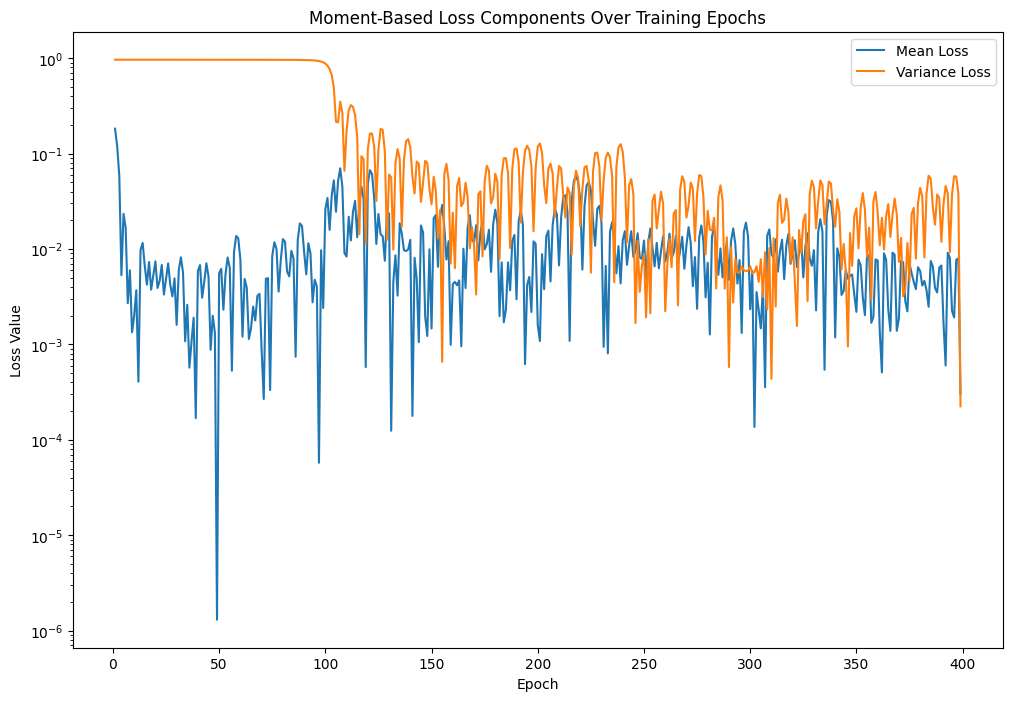

In [18]:
# Plot each loss component
plt.figure(figsize=(12, 8))
plt.yscale('log')
plt.plot(epoch_list, mean_loss_list, label="Mean Loss")
plt.plot(epoch_list, variance_loss_list, label="Variance Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.title("Moment-Based Loss Components Over Training Epochs")
plt.legend()
plt.show()

Text(0, 0.5, '$l_2$')

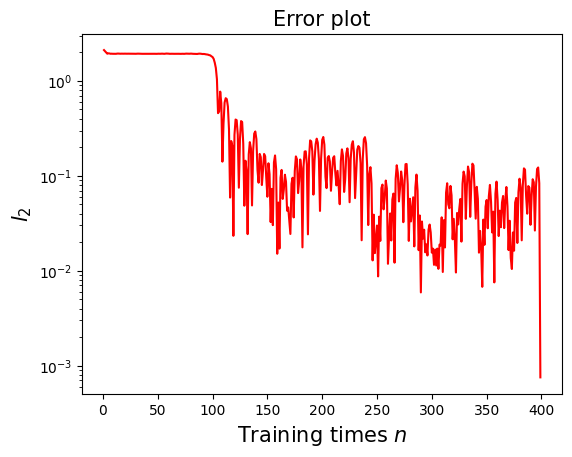

In [19]:
fig = plt.figure(1)
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
plt.title("Error plot",fontsize=15) 
plt.yscale('log')
plt.plot(epoch_list, total_loss_list,'r',label='Training error')
plt.xlabel(r'Training times $n$',fontsize=15)
plt.ylabel(r'$l_1$',fontsize=15)

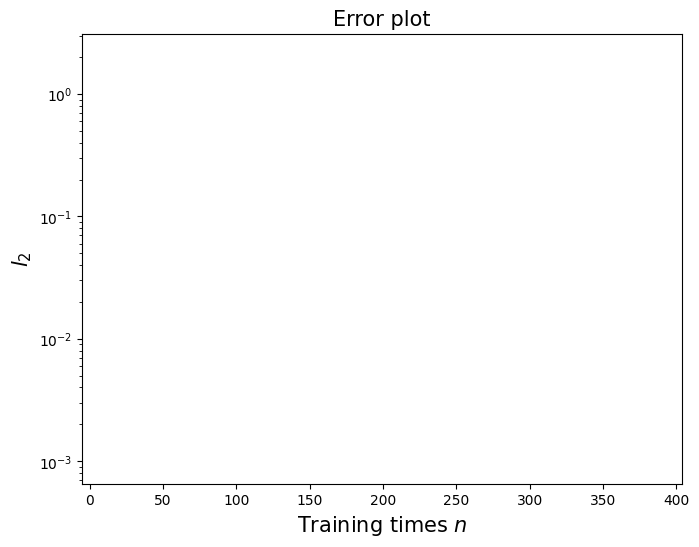

In [20]:
# Initialize figure
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])
ax.set_title("Error plot", fontsize=15)
ax.set_xlabel(r'Training times $n$', fontsize=15)
ax.set_ylabel(r'$l_1$', fontsize=15)
ax.set_yscale('log')  # Use logarithmic scale for better visualization
ax.set_xlim(-5, epoch_list[-1]+5)  # Initial x-axis limit
ax.set_ylim(min(total_loss_list)-0.0001, max(total_loss_list)+1)  # Set y-axis limit

# Initialize line plot object (empty initially)
line, = ax.plot([], [], 'r', label='Training error')

# Function to update the plot in the animation
def update_plot(frame):
    # Show 10 more points at each frame
    end_index = (frame + 1) * 10
    epoch_data = epoch_list[:end_index]
    loss_data = total_loss_list[:end_index]
    
    # Update the line data
    line.set_data(epoch_data, loss_data)
    
    # Update the title to reflect the current epoch range
    ax.set_title(f"Error plot from Epoch 1 to Epoch {epoch_data[-1]}", fontsize=15)
    
    return line,

# Number of frames to show (every 10 epochs)
num_frames = len(epoch_list) // 10  # Adjust for how many epochs you have
if len(epoch_list) % 10 != 0:
    num_frames += 1

# Create the animation
anim = FuncAnimation(fig, update_plot, frames=num_frames, interval=500, repeat=False)

# Show the animation
plt.show()

# Optionally save the animation as a GIF
anim.save("error_plot_animation.gif", writer="pillow", fps=2)


In [21]:
from matplotlib.animation import FuncAnimation

# Set the input for testing the transformation
input_test = torch.tensor(np.linspace(0, 1, batch_size).astype(np.float32)).unsqueeze(1)
uniform_samples_np = uniform_samples.numpy()
gaussian_samples_np = gaussian_samples.numpy()

In [22]:
# Function to load model and transform samples
def load_and_transform(model, model_path, input_test):
    model.load_state_dict(torch.load(model_path))
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():
        transformed_samples = model(input_test)
    return transformed_samples.numpy()

In [23]:
# Get list of saved models sorted by creation time
model_files = sorted(glob.glob("model_epoch_*.pt"), key=os.path.getmtime)

if not model_files:
    print("No model files found.")
else:
    # Collect transformed samples for each saved model
    transformed_samples_list = [load_and_transform(model, path, input_test) for path in model_files]

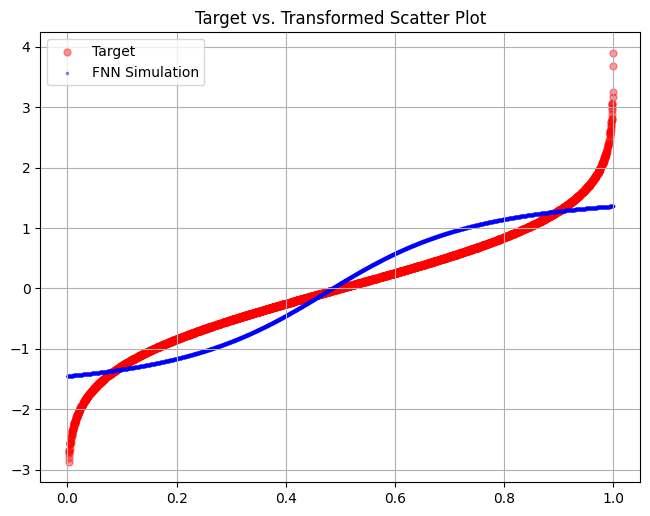

In [24]:
# Set up the figure with two subplots
fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_axes([0.15, 0.15, 0.75, 0.75])

# Scatter plot
scatter_target = ax.scatter(uniform_samples_np, gaussian_samples_np, c='r', s=25, alpha=0.4, marker='o', label='Target')
scatter_sim = ax.scatter(input_test.numpy(), transformed_samples_list[-1], c='b', s=10, alpha=0.4, marker='.', label='FNN Simulation')
ax.legend()
ax.set_title("Target vs. Transformed Scatter Plot")
ax.grid(True)


In [25]:
# Animation function
def animate(i):
    # Update scatter plot for FNN simulation
    epoch = int(model_files[i].split('_')[-1].split('.')[0])
    scatter_sim.set_offsets(np.c_[input_test.numpy(), transformed_samples_list[i]])
    ax.set_title(f"Scatter Plot at Epoch {epoch}")

In [26]:
# Create the animation
anim = FuncAnimation(fig, animate, frames=len(transformed_samples_list), interval=500)
%matplotlib inline
# Display the animation
plt.show()
# Save animation
anim.save("training_animation.gif", writer="pillow", fps=2)

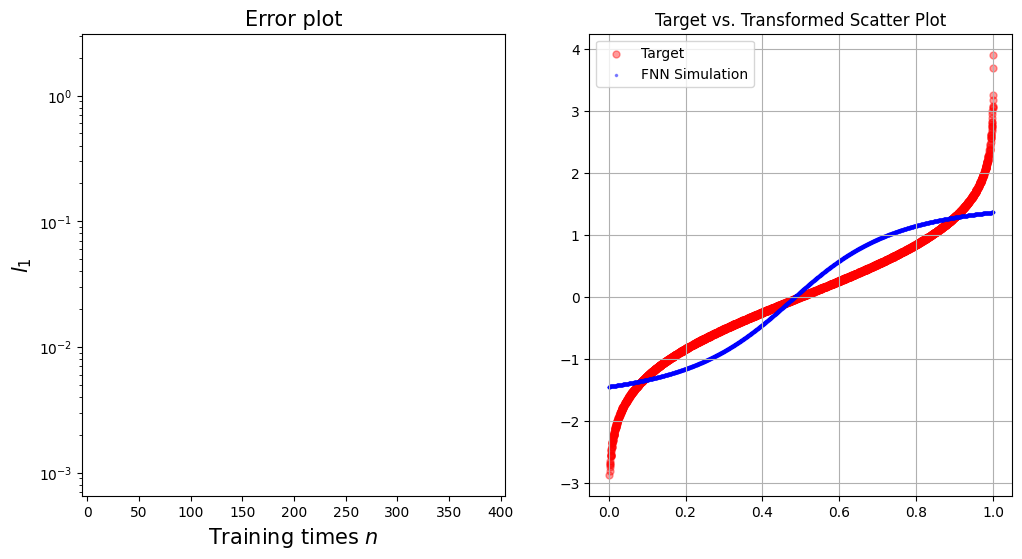

In [43]:
# Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Total loss plot (ax1)
ax1.set_title("Error plot", fontsize=15)
ax1.set_xlabel(r'Training times $n$', fontsize=15)
ax1.set_ylabel(r'$l_1$', fontsize=15)
ax1.set_yscale('log')  # Use logarithmic scale for better visualization
ax1.set_xlim(-5, epoch_list[-1]+5)  # Initial x-axis limit
ax1.set_ylim(min(total_loss_list)-0.0001, max(total_loss_list)+1)  # Set y-axis limit
line, = ax1.plot([], [], 'r', label='Training error')

# Scatter plot (ax2)
scatter_target = ax2.scatter(uniform_samples_np, gaussian_samples_np, c='r', s=25, alpha=0.4, marker='o', label='Target')
scatter_sim = ax2.scatter(input_test.numpy(), transformed_samples_list[-1], c='b', s=10, alpha=0.4, marker='.', label='FNN Simulation')
ax2.legend()
ax2.set_title("Target vs. Transformed Scatter Plot")
ax2.grid(True)

# Function to update both the total loss plot and scatter plot
def update_plot(frame):
    # Update total loss plot (ax1)
    end_index = (frame + 1) * 10
    epoch_data = epoch_list[:end_index]
    loss_data = total_loss_list[:end_index]
    line.set_data(epoch_data, loss_data)
    
    # Update scatter plot (ax2) for FNN simulation
    scatter_sim.set_offsets(np.c_[input_test.numpy(), transformed_samples_list[frame]])
    
    # Update titles
    ax1.set_title(f"Error plot from Epoch 1 to Epoch {epoch_data[-1]}", fontsize=15)
    ax2.set_title(f"Scatter Plot at Epoch {frame * 10}", fontsize=15)
    
    return line, scatter_sim  # Return the updated plot elements

# Number of frames to show (every 10 epochs)
num_frames = len(epoch_list) // 10  # Adjust for how many epochs you have
if len(epoch_list) % 10 != 0:
    num_frames += 1

# Create the combined animation
anim = FuncAnimation(fig, update_plot, frames=num_frames, interval=500, repeat=False)

# Show the animation
plt.show()

# Optionally, save the animation as a GIF
anim.save("combined_training_animation.gif", writer="pillow", fps=10)

In [28]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples = model(input_test)


# Convert tensors to numpy for visualization
transformed_samples_np = transformed_samples.numpy()

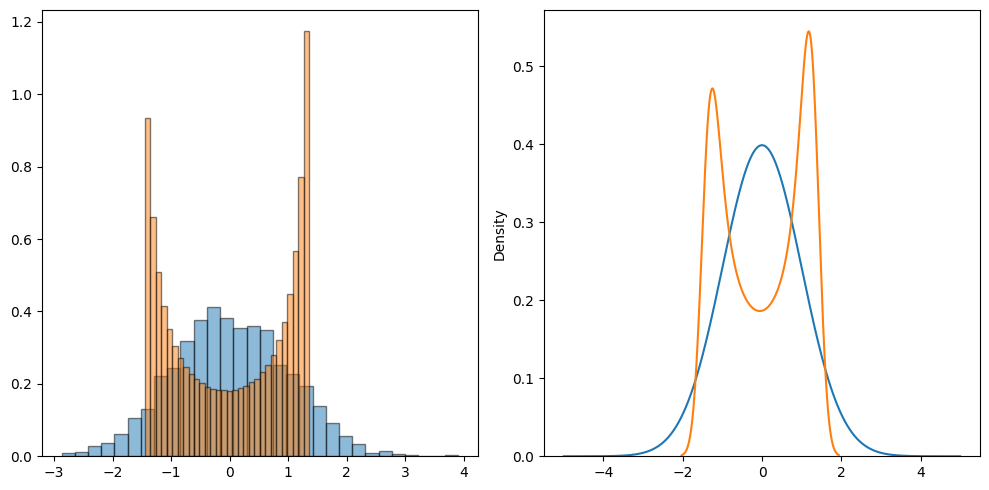

In [29]:
# Step 7: Plot the original and transformed distributions
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
# plt.title('Gaussian vs Transformed Distribution')
# plt.legend()

plt.subplot(1, 2, 2)
# Gaussian distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Frequency')

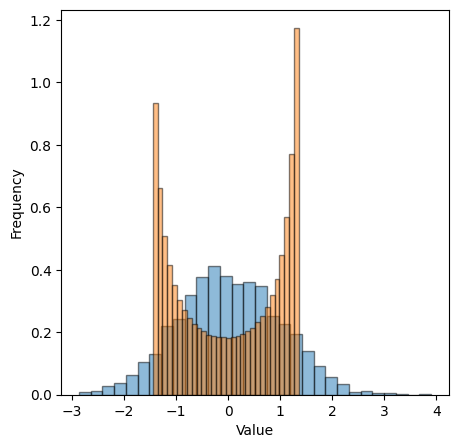

In [30]:
plt.figure(figsize=(5, 5))
plt.hist(gaussian_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.hist(transformed_samples_np, bins=30, alpha=0.5, density=True, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
# plt.title('Gaussian vs Transformed Distribution')

(0.0, 0.71)

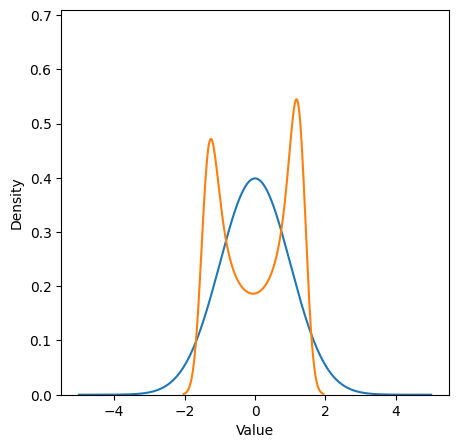

In [39]:
plt.figure(figsize=(5, 5))
# Normal distribution with Mean = 0, SD = 1.
x_axis = np.arange(-5, 5, 0.0005)
plt.plot(x_axis, norm.pdf(x_axis,0,1))
sns.kdeplot(transformed_samples.cpu().reshape(batch_size))
# plt.title('Gaussian vs Transformed Distribution')
plt.xlabel('Value')
plt.ylim(0, 0.71)

In [32]:
# Test the transformation from final model
with torch.no_grad():
    transformed_samples1 = model(uniform_samples)


print(torch.mean(transformed_samples1))
print(compute_variance(transformed_samples1))

tensor(0.0194)
tensor(1.0195)


In [33]:
print(compute_mean(gaussian_samples))
print(compute_variance(gaussian_samples))

tensor(0.0213, dtype=torch.float64)
tensor(0.9631, dtype=torch.float64)


In [34]:
type(transformed_samples_list[-1])

numpy.ndarray

In [35]:
np.mean(transformed_samples_list[-1])-compute_mean(gaussian_samples)

tensor(-0.0090, dtype=torch.float64)

In [36]:
np.var(transformed_samples_list[-1])-compute_variance(gaussian_samples)

tensor(0.0581, dtype=torch.float64)